<a href="https://colab.research.google.com/github/khu3086/FastAICourse/blob/main/Lec03_Notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 4 — Training a Digit Classifier (Fast.ai)
## Study Notebook: Code + Explanations

```markdown
## 1. Dataset Loading
```

In [20]:
from fastai.vision.all import *

path = untar_data(URLs.MNIST_SAMPLE)
Path.BASE_PATH = path

path.ls()

[Path('train'), Path('valid'), Path('labels.csv')]

```markdown
Output: (L) 2 items: [Path('train'), Path('valid')]
```

In [21]:
(path/'train').ls()

[Path('train/7'), Path('train/3')]

```markdown
Output: (L) 2 items: [Path('train/3'), Path('train/7')]
```

In [22]:
threes = (path/'train'/'3').ls().sorted()
sevens = (path/'train'/'7').ls().sorted()
# .sorted() ensures consistent ordering across environments

```markdown
## 2. Viewing an Image as a Tensor
```

In [23]:
from PIL import Image

im3_path = threes[1]
im3 = Image.open(im3_path)    # PIL image object
im3                            # displays image in notebook

# Convert to NumPy array and slice a 6x6 sub-grid
array(im3)[4:10, 4:10]

# Same thing as a PyTorch tensor
tensor(im3)[4:10, 4:10]

# Each value is a pixel intensity: 0 (black) → 255 (white)

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  29],
        [  0,   0,   0,  48, 166, 224],
        [  0,  93, 244, 249, 253, 187],
        [  0, 107, 253, 253, 230,  48],
        [  0,   3,  20,  20,  15,   0]], dtype=torch.uint8)

```markdown
## 3. Stacking Images into a Rank-3 Tensor
```

In [24]:
# Load all images as tensors
seven_tensors = [tensor(Image.open(o)) for o in sevens]
three_tensors = [tensor(Image.open(o)) for o in threes]

# Stack into a single tensor: (num_images, H, W)
stacked_sevens = torch.stack(seven_tensors).float() / 255
stacked_threes = torch.stack(three_tensors).float() / 255

# torch.stack() adds a new leading dimension
# .float()  → converts uint8 to float32
# / 255     → normalises pixel values to [0.0, 1.0]

print(stacked_threes.shape)   # torch.Size([6131, 28, 28])
print(stacked_threes.ndim)    # 3  (rank = number of axes)
print(stacked_threes[0].shape) # torch.Size([28, 28]) — single image

torch.Size([6131, 28, 28])
3
torch.Size([28, 28])


```markdown
## 4. Computing the Mean ("Ideal") Digit
```

torch.Size([28, 28])


<Axes: >

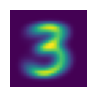

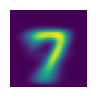

In [25]:
# Average across dimension 0 (across all images)
mean3 = stacked_threes.mean(0)
mean7 = stacked_sevens.mean(0)

print(mean3.shape)   # torch.Size([28, 28])

show_image(mean3)    # blurry "average 3"
show_image(mean7)    # blurry "average 7"

# Intuition: the "ideal" digit — if a new image looks like this,
# it's probably that digit.

```markdown
## 5. Distance Metrics (L1 and L2)
```

In [26]:
import torch.nn.functional as F

a_3 = stacked_threes[1]   # one test image

# --- L1: Mean Absolute Difference ---
dist_3_abs = (a_3 - mean3).abs().mean()
dist_7_abs = (a_3 - mean7).abs().mean()
print(dist_3_abs, dist_7_abs)
# tensor(0.1114) tensor(0.1586) → closer to mean3 ✓

# --- L2: Root Mean Squared Error (RMSE) ---
dist_3_sqr = ((a_3 - mean3)**2).mean().sqrt()
dist_7_sqr = ((a_3 - mean7)**2).mean().sqrt()
print(dist_3_sqr, dist_7_sqr)
# tensor(0.2021) tensor(0.3021) → closer to mean3 ✓

# --- PyTorch built-ins ---
F.l1_loss(a_3.float(), mean7)        # L1
F.mse_loss(a_3, mean7).sqrt()        # RMSE (mse_loss alone = mean square, not root)

tensor(0.1114) tensor(0.1586)
tensor(0.2021) tensor(0.3021)


tensor(0.3021)

```markdown
## 6. Pixel Similarity Classifier (Baseline ~90% accuracy)
```

In [27]:
# Load validation images
valid_3_tens = torch.stack([tensor(Image.open(o))
                            for o in (path/'valid'/'3').ls()])
valid_3_tens = valid_3_tens.float() / 255

valid_7_tens = torch.stack([tensor(Image.open(o))
                            for o in (path/'valid'/'7').ls()])
valid_7_tens = valid_7_tens.float() / 255

# mean((-1,-2)) = reduce over last two axes (H, W) → one scalar per image
def mnist_distance(a, b):
    return (a - b).abs().mean((-1, -2))

# Broadcasting: valid_3_tens [1010,28,28] − mean3 [28,28] works automatically
dist_3 = mnist_distance(valid_3_tens, mean3)   # shape [1010]

# Classify: is this image closer to mean3 or mean7?
def is_3(x):
    return mnist_distance(x, mean3) < mnist_distance(x, mean7)

accuracy_3s =       is_3(valid_3_tens).float().mean()
accuracy_7s = (1 - is_3(valid_7_tens).float()).mean()

print((accuracy_3s + accuracy_7s) / 2)   # ≈ 0.90 — no learning at all!

tensor(0.9511)


```markdown
## 7. Broadcasting (Concept Demonstration)
```

In [28]:
# Rule: PyTorch pads the smaller tensor's shape with 1s on the left,
# then expands size-1 dims to match the larger tensor. No data is copied.

# valid_3_tens: [1010, 28, 28]
# mean3:           [28, 28]  → padded to [1, 28, 28] → expanded to [1010, 28, 28]

diff = valid_3_tens - mean3   # shape: [1010, 28, 28] — no loop needed
diff.abs().mean((-1, -2))     # shape: [1010]

# Broadcasting fails if neither dim is 1 and they don't match → runtime error

tensor([0.1032, 0.1464, 0.1423,  ..., 0.1366, 0.1285, 0.1120])

```markdown
## 8. SGD from Scratch (Quadratic Example)
```

In [29]:
# Toy example: fit y = ax^2 + bx + c to (time, speed) data
time  = torch.arange(0, 20).float()
speed = torch.randn(20) + 0.75 * (time - 9.5)**2 + 1

def f(t, params):
    a, b, c = params
    return a * t**2 + b * t + c

def mse(preds, targets):
    return ((preds - targets)**2).mean()

# 1. Initialise parameters with requires_grad_ so PyTorch tracks ops
params = torch.randn(3).requires_grad_()

# 2–6. Training loop
lr = 1e-5
for _ in range(1000):
    preds = f(time, params)             # forward pass
    loss  = mse(preds, speed)          # compute loss
    loss.backward()                    # compute gradients → params.grad
    params.data -= lr * params.grad    # update weights (.data avoids tracking)
    params.grad.zero_()                # IMPORTANT: reset grads (else they accumulate)

print(params)

tensor([ 0.1456, -0.2579,  1.4896], requires_grad=True)


```markdown
## 9. Linear Model for MNIST
```

In [30]:
# Flatten each 28×28 image into a 784-element vector
# torch.cat() concatenates along axis 0
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28*28)
# shape: [12396, 784]

# Labels: 1 = three, 0 = seven
# .unsqueeze(1) adds a size-1 dim → [12396, 1] (needed for matmul)
train_y = tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1)

dset = list(zip(train_x, train_y))

# Initialise weights and bias
def init_params(size, std=1.0):
    return (torch.randn(size) * std).requires_grad_()

weights = init_params((28*28, 1))   # shape [784, 1]
bias    = init_params(1)

# @ is Python's matrix-multiply operator
# xb [batch, 784] @ weights [784, 1] + bias → [batch, 1]
def linear1(xb):
    return xb @ weights + bias

# Check: raw predictions before training
xb, yb = dset[0]
print(linear1(train_x[:5]))   # random values before any training

tensor([[2.1860],
        [2.6170],
        [2.0218],
        [3.0813],
        [1.9706]], grad_fn=<AddBackward0>)


```markdown
## 10. Loss Function and Sigmoid
```

In [31]:
import torch

# Sigmoid: maps any real number to (0, 1)
# σ(x) = 1 / (1 + e^(−x))
# At x=0 → 0.5 (maximum uncertainty)
print(torch.sigmoid(tensor([-10., -5., 0., 5., 10.])))
# tensor([4.5e-05, 0.0067, 0.5000, 0.9933, 1.0])

# Binary cross-entropy loss for MNIST
# torch.where(cond, a, b) → picks a where cond is True, b where False
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets == 1,
                       1 - predictions,   # loss for positives (3s)
                       predictions        # loss for negatives (7s)
                      ).mean()

# When model is confident AND correct → loss near 0
# When model is confident AND wrong  → loss near 1

tensor([4.5398e-05, 6.6929e-03, 5.0000e-01, 9.9331e-01, 9.9995e-01])


```markdown
## 11. DataLoader and Batch Accuracy
```

In [32]:
from torch.utils.data import DataLoader

# Build validation dataset
valid_x = torch.cat([valid_3_tens, valid_7_tens]).view(-1, 28*28)
valid_y = tensor([1]*len(valid_3_tens) + [0]*len(valid_7_tens)).unsqueeze(1)

train_dset = list(zip(train_x, train_y))
valid_dset = list(zip(valid_x, valid_y))

# DataLoader batches data and shuffles training set each epoch
dl       = DataLoader(train_dset, batch_size=256, shuffle=True)
valid_dl = DataLoader(valid_dset, batch_size=256)

xb, yb = first(dl)
print(xb.shape, yb.shape)   # [256, 784]  [256, 1]

# Accuracy for one batch
def batch_accuracy(xb, yb):
    preds   = xb.sigmoid()           # raw scores → probabilities
    correct = (preds > 0.5) == yb    # boolean: correct prediction?
    return correct.float().mean()    # fraction correct

torch.Size([256, 784]) torch.Size([256, 1])


```markdown
## 12. Full Training Loop
```

In [33]:
from torch import optim

# PyTorch built-in SGD optimizer
# opt.step()      → applies param -= lr * grad
# opt.zero_grad() → resets all .grad to None (prevents accumulation)
opt = optim.SGD([weights, bias], lr=1.0)

def calc_grad(xb, yb, model):
    preds = model(xb)
    loss  = mnist_loss(preds, yb)
    loss.backward()   # fills .grad for all requires_grad tensors

def validate_epoch(model):
    accs = [batch_accuracy(model(xb), yb) for xb, yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

# Training loop — one epoch = one pass over all mini-batches
for epoch in range(20):
    for xb, yb in dl:
        calc_grad(xb, yb, linear1)
        opt.step()
        opt.zero_grad()
    print(validate_epoch(linear1), end=' ')

# After 20 epochs, linear model reaches ~0.98 accuracy

0.8769 0.924 0.9406 0.949 0.9519 0.9554 0.9578 0.9598 0.9613 0.9622 0.9637 0.9652 0.9657 0.9666 0.9671 0.9676 0.9681 0.9681 0.9681 0.9681 

```markdown
## 13. Using fastai's Learner (Same Result, Less Boilerplate)
```

In [18]:
import torch.nn as nn
from fastai.data.all import DataLoaders
from fastai.learner import Learner
from fastai.optimizer import SGD

linear_model = nn.Linear(28*28, 1)
# Equivalent to: xb @ weight.T + bias
# Automatically creates and registers weights + bias

dls = DataLoaders(dl, valid_dl)

learn = Learner(dls, linear_model,
                opt_func=SGD,
                loss_func=mnist_loss,
                metrics=batch_accuracy)

learn.fit(10, lr=1.0)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.058420,0.043351,0.971050,00:01
1,0.040267,0.035387,0.974975,00:00
2,0.032130,0.031527,0.975957,00:00
3,0.028422,0.029933,0.977429,00:00
4,0.025676,0.028245,0.977920,00:00
5,0.023749,0.027293,0.978410,00:00
6,0.022275,0.026909,0.978410,00:00
7,0.021402,0.025522,0.979392,00:00
8,0.020922,0.025259,0.979882,00:00
9,0.020181,0.025167,0.980373,00:00


```markdown
## 14. Adding a Non-linearity: Two-Layer Neural Network
```

In [34]:
# Problem with linear models:
# W2 @ (W1 @ x) = (W2@W1) @ x  → still linear, no extra power
# Solution: insert a non-linear activation between layers

# ReLU(x) = max(0, x)
# Zeros out negatives, passes positives through unchanged

simple_net = nn.Sequential(
    nn.Linear(28*28, 30),   # hidden layer: 784 → 30 features
    nn.ReLU(),              # non-linearity (makes composition non-trivial)
    nn.Linear(30, 1)        # output layer: 30 features → 1 prediction
)
# Total parameters: (784×30 + 30) + (30×1 + 1) = 23,552

learn = Learner(dls, simple_net,
                opt_func=SGD,
                loss_func=mnist_loss,
                metrics=batch_accuracy)

learn.fit(40, 0.1)
# After 40 epochs → ~0.9999 accuracy (near-perfect on 3-vs-7)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.222304,0.090178,0.967125,00:00
1,0.106767,0.054026,0.968106,00:00
2,0.066429,0.044460,0.969578,00:00
3,0.048284,0.039857,0.971050,00:00
4,0.038843,0.036960,0.971050,00:00
5,0.033916,0.034438,0.973994,00:00
6,0.030782,0.033109,0.975466,00:00
7,0.028271,0.031558,0.975957,00:00
8,0.027291,0.030483,0.976448,00:00
9,0.025668,0.029703,0.975957,00:00


```markdown
## 15. Going Deeper: ResNet-18 via fastai
```

In [38]:
from fastai.vision.all import *

# Full 18-layer ResNet — hierarchical feature learning
dls = ImageDataLoaders.from_folder(path)

learn = vision_learner(dls, resnet18,
                       pretrained=False,       # train from scratch
                       loss_func=F.cross_entropy,
                       metrics=accuracy)

learn.fit_one_cycle(5, 0.1)
# fit_one_cycle uses 1cycle LR schedule — faster and more stable than fixed LR
# Achieves near-perfect accuracy and generalises to all 10 digit classes

epoch,train_loss,valid_loss,accuracy,time
0,0.174906,0.194675,0.968106,00:10
1,0.271140,0.027563,0.995584,00:10
2,0.054348,0.014531,0.995584,00:10
3,0.025532,0.008138,0.997056,00:10
4,0.005524,0.005666,0.998528,00:10


```markdown
## Quick Reference Summary
```

In [41]:
# --- Key tensor operations ---
# torch.stack(list_of_tensors)         # new leading dim
# torch.cat([t1, t2], dim=0)          # concat along existing dim
# t.view(-1, 784)                     # reshape (-1 = infer)
# t.unsqueeze(1)                      # insert size-1 dim at position 1
# t.mean(0)                           # reduce axis 0
# t.mean((-1,-2))                     # reduce last two axes (H, W)

# --- Autograd ---
# t = torch.randn(3).requires_grad_() # enable gradient tracking
# loss.backward()                     # compute all gradients
# t.grad                              # d(loss)/d(t)
# t.data -= lr * t.grad               # update without tracking
# t.grad.zero_()                      # reset (MUST do before next backward)

# --- Loss and activation ---
# torch.sigmoid(x)                    # squash to (0,1)
# torch.where(cond, a, b)             # element-wise conditional pick
# F.l1_loss(a, b)                     # mean absolute error
# F.mse_loss(a, b)                    # mean squared error (not root)

# --- Model building ---
# nn.Linear(in_features, out_features)                  # learnable xb @ W.T + b
# nn.ReLU()                           # max(0, x)
# nn.Sequential(l1, l2, l3)          # chain layers in order

# --- Training essentials ---
# opt.step()                          # apply weight update
# opt.zero_grad()                     # reset gradients
# DataLoader(dset, batch_size=256, shuffle=True)